In [ ]:
!pip install yfinance xgboost pandas numpy scikit-learn matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
start_date = "2015-01-01"
end_date = "2024-01-01"

qqq = yf.download("QQQ", start=start_date, end=end_date)['Close']
qqq.name = 'QQQ_USD'
gld = yf.download("GLD", start=start_date, end=end_date)['Close']
gld.name = 'GLD_USD'
usd_thb = yf.download("USDTHB=X", start=start_date, end=end_date)['Close']
usd_thb.name = 'USD_THB'
vix = yf.download("^VIX", start=start_date, end=end_date)['Close']
vix.name = 'VIX'
tnx = yf.download("^TNX", start=start_date, end=end_date)['Close']
tnx.name = 'TNX'

data = pd.concat([qqq, gld, usd_thb, vix, tnx], axis=1).dropna()

/tmp/ipykernel_13014/2383626752.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  qqq = yf.download("QQQ", start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_13014/2383626752.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gld = yf.download("GLD", start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_13014/2383626752.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_thb = yf.download("USDTHB=X", start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_13014/2383626752.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start=start_date, end=end_date)['Close']
[*********************100%********************

In [ ]:
# feature engineering
print("Engineering features...")
# 1. Convert assets to THB
data['QQQ_THB'] = data['QQQ'] * data['USDTHB=X']
data['GLD_THB'] = data['GLD'] * data['USDTHB=X']

# 2. Create Technical Indicators (Features)
for asset in ['QQQ_THB', 'GLD_THB']:
    # Daily Returns
    data[f'{asset}_Ret'] = data[asset].pct_change()
    # Simple Moving Averages
    data[f'{asset}_SMA20'] = data[asset].rolling(window=20).mean()
    data[f'{asset}_SMA50'] = data[asset].rolling(window=50).mean()
    # Volatility (Rolling standard deviation)
    data[f'{asset}_Vol20'] = data[f'{asset}_Ret'].rolling(window=20).std()

# 3. Create Target Variables (Shifted by -1 so today's features predict tomorrow's move)
# Target is 1 if tomorrow's return is greater than the 0.3% fee
fee_threshold = 0.003
data['QQQ_Target'] = (data['QQQ_THB'].pct_change().shift(-1) > fee_threshold).astype(int)
data['GLD_Target'] = (data['GLD_THB'].pct_change().shift(-1) > fee_threshold).astype(int)

# Drop NaN values created by rolling windows and shifting
data.dropna(inplace=True)

# Define feature columns
features = [
    'QQQ_THB_Ret', 'QQQ_THB_SMA20', 'QQQ_THB_SMA50', 'QQQ_THB_Vol20',
    'GLD_THB_Ret', 'GLD_THB_SMA20', 'GLD_THB_SMA50', 'GLD_THB_Vol20',
    '^VIX', '^TNX', 'USDTHB=X'
]

Engineering features...


In [ ]:
# back testing
def run_backtest(df, start_idx, end_idx, title):
    print(f"\n--- Backtesting: {title} ({start_idx.date()} to {end_idx.date()}) ---")

    test_data = df.loc[start_idx:end_idx].copy()

    initial_capital = 1000000.0
    fee_rate = 0.003

    # Hysteresis Thresholds
    buy_threshold = 0.60
    sell_threshold = 0.40

    cash = initial_capital
    qqq_shares = 0
    gld_shares = 0
    ml_portfolio_values = []

    base_cash = initial_capital
    base_qqq_shares = (base_cash * 0.5) * (1 - fee_rate) / test_data['QQQ_THB'].iloc[0]
    base_gld_shares = (base_cash * 0.5) * (1 - fee_rate) / test_data['GLD_THB'].iloc[0]
    base_cash = 0
    base_portfolio_values = []

    for index, row in test_data.iterrows():
        current_qqq_price = row['QQQ_THB']
        current_gld_price = row['GLD_THB']

        current_portfolio_value = cash + (qqq_shares * current_qqq_price) + (gld_shares * current_gld_price)
        ml_portfolio_values.append(current_portfolio_value)

        base_value = base_cash + (base_qqq_shares * current_qqq_price) + (base_gld_shares * current_gld_price)
        base_portfolio_values.append(base_value)

        # 1. Evaluate QQQ
        qqq_uptrend = current_qqq_price > row['QQQ_THB_SMA50']
        if qqq_shares == 0:
            # Only buy if confident AND asset is above its 50-day average
            target_qqq_allocation = 0.5 if (row['QQQ_Prob'] > buy_threshold and qqq_uptrend) else 0.0
        else:
            # We already own it, don't sell unless confidence drops below sell threshold
            target_qqq_allocation = 0.5 if row['QQQ_Prob'] > sell_threshold else 0.0

        # 2. Evaluate GLD
        gld_uptrend = current_gld_price > row['GLD_THB_SMA50']
        if gld_shares == 0:
            # Only buy if confident AND asset is above its 50-day average
            target_gld_allocation = 0.5 if (row['GLD_Prob'] > buy_threshold and gld_uptrend) else 0.0
        else:
            target_gld_allocation = 0.5 if row['GLD_Prob'] > sell_threshold else 0.0

        # EXECUTION
        target_qqq_value = current_portfolio_value * target_qqq_allocation
        target_gld_value = current_portfolio_value * target_gld_allocation

        # Rebalance QQQ
        current_qqq_value = qqq_shares * current_qqq_price
        if target_qqq_value > current_qqq_value and qqq_shares == 0: # Buy
            buy_amount = target_qqq_value
            fee = buy_amount * fee_rate
            if cash >= (buy_amount + fee):
                cash -= (buy_amount + fee)
                qqq_shares += buy_amount / current_qqq_price
        elif target_qqq_value == 0 and qqq_shares > 0: # Sell to Cash
            sell_amount = qqq_shares * current_qqq_price
            fee = sell_amount * fee_rate
            cash += (sell_amount - fee)
            qqq_shares = 0

        # Rebalance GLD
        current_gld_value = gld_shares * current_gld_price
        if target_gld_value > current_gld_value and gld_shares == 0: # Buy
            buy_amount = target_gld_value
            fee = buy_amount * fee_rate
            if cash >= (buy_amount + fee):
                cash -= (buy_amount + fee)
                gld_shares += buy_amount / current_gld_price
        elif target_gld_value == 0 and gld_shares > 0: # Sell to Cash
            sell_amount = gld_shares * current_gld_price
            fee = sell_amount * fee_rate
            cash += (sell_amount - fee)
            gld_shares = 0

    test_data['ML_Strategy'] = ml_portfolio_values
    test_data['Baseline'] = base_portfolio_values

    def calc_metrics(series):
        returns = series.pct_change().dropna()
        cum_return = (series.iloc[-1] / series.iloc[0]) - 1
        annualized = (1 + cum_return) ** (252 / len(series)) - 1 if len(series) > 0 else 0
        volatility = returns.std() * np.sqrt(252)
        sharpe = annualized / volatility if volatility > 0 else 0
        running_max = series.cummax()
        drawdown = (series - running_max) / running_max
        max_dd = drawdown.min()
        return cum_return, annualized, volatility, sharpe, max_dd

    ml_metrics = calc_metrics(test_data['ML_Strategy'])
    base_metrics = calc_metrics(test_data['Baseline'])

    print(f"{'Metric':<15} | {'ML Strategy':<15} | {'Baseline (Buy&Hold)'}")
    print("-" * 55)
    print(f"{'Cum. Return':<15} | {ml_metrics[0]:.2%} {'':<6} | {base_metrics[0]:.2%}")
    print(f"{'Ann. Return':<15} | {ml_metrics[1]:.2%} {'':<6} | {base_metrics[1]:.2%}")
    print(f"{'Volatility':<15} | {ml_metrics[2]:.2%} {'':<6} | {base_metrics[2]:.2%}")
    print(f"{'Sharpe Ratio':<15} | {ml_metrics[3]:.2f} {'':<7} | {base_metrics[3]:.2f}")
    print(f"{'Max Drawdown':<15} | {ml_metrics[4]:.2%} {'':<6} | {base_metrics[4]:.2%}")

    plt.figure(figsize=(10, 5))
    plt.plot(test_data.index, test_data['ML_Strategy'], label='ML Strategy', color='blue')
    plt.plot(test_data.index, test_data['Baseline'], label='Baseline (Buy & Hold)', color='orange')
    plt.title(f'Portfolio Value (THB) - {title}')
    plt.ylabel('Portfolio Value (THB)')
    plt.legend()
    plt.grid(True)
    plt.show()


Training Models for Period 1: 2021 Mid-Year (Bull Market)...

--- Backtesting: Period 1: 2021 Mid-Year (Bull Market) (2021-07-01 to 2021-12-31) ---
Metric          | ML Strategy     | Baseline (Buy&Hold)
-------------------------------------------------------
Cum. Return     | -2.08%        | 12.19%
Ann. Return     | -4.04%        | 25.42%
Volatility      | 7.04%        | 11.48%
Sharpe Ratio    | -0.57         | 2.21
Max Drawdown    | -4.41%        | -3.73%


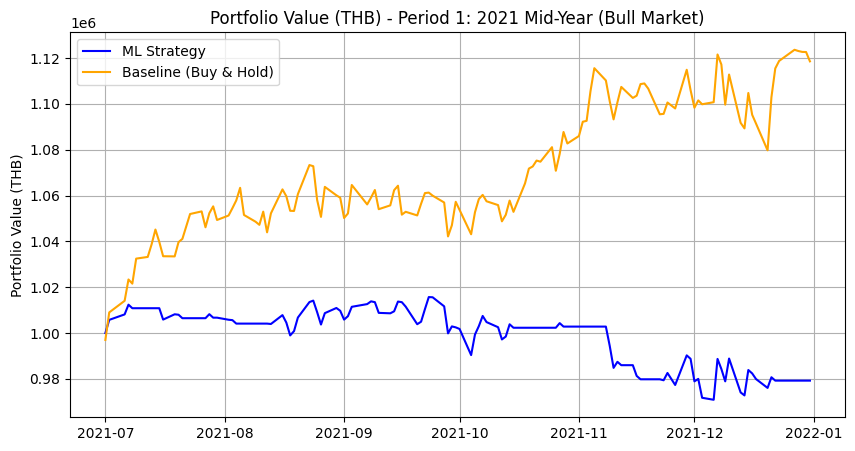


Training Models for Period 2: 2022-2023 (Bear Market & Rate Hikes)...

--- Backtesting: Period 2: 2022-2023 (Bear Market & Rate Hikes) (2022-01-01 to 2023-12-29) ---
Metric          | ML Strategy     | Baseline (Buy&Hold)
-------------------------------------------------------
Cum. Return     | 15.65%        | 12.35%
Ann. Return     | 7.59%        | 6.03%
Volatility      | 12.84%        | 16.96%
Sharpe Ratio    | 0.59         | 0.36
Max Drawdown    | -13.67%        | -15.85%


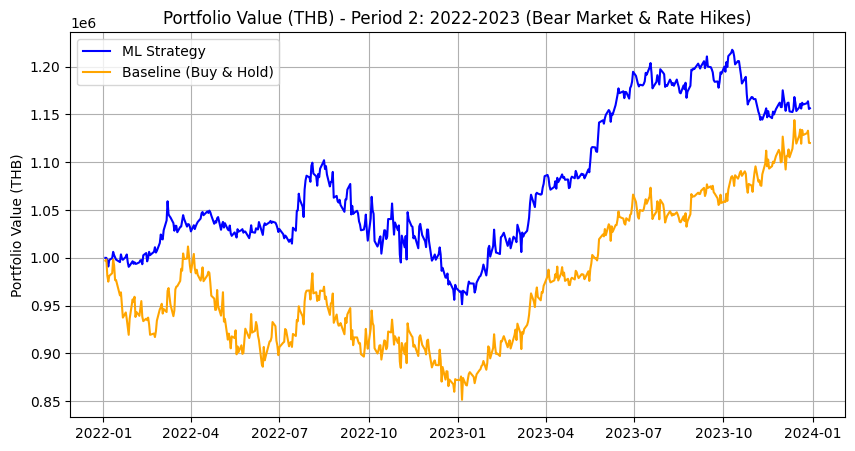

In [ ]:
# training
def train_and_predict(train_start, train_end, test_start, test_end, period_name):
    print(f"\nTraining Models for {period_name}...")
    train = data.loc[train_start:train_end]
    test = data.loc[test_start:test_end]

    X_train, y_train_qqq, y_train_gld = train[features], train['QQQ_Target'], train['GLD_Target']
    X_test = test[features]

    # Model 1: Random Forest for QQQ
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train_qqq)
    data.loc[test_start:test_end, 'QQQ_Prob'] = rf_model.predict_proba(X_test)[:, 1]

    # Model 2: XGBoost for GLD
    xgb_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
    xgb_model.fit(X_train, y_train_gld)
    data.loc[test_start:test_end, 'GLD_Prob'] = xgb_model.predict_proba(X_test)[:, 1]

    # Run Backtest
    run_backtest(data, pd.to_datetime(test_start), pd.to_datetime(test_end), period_name)

# --- EXECUTE PERIOD 1 (2021 Bull Market) ---
# Adjusted periods to fit available data (data starts 2021-01-04 after feature engineering and dropna)
train_and_predict(train_start="2021-01-04", train_end="2021-06-30",
                  test_start="2021-07-01", test_end="2021-12-31",
                  period_name="Period 1: 2021 Mid-Year (Bull Market)")

# --- EXECUTE PERIOD 2 (2022-2023 Bear Market & Rate Hikes) ---
# Adjusted periods to fit available data (data ends 2023-12-29)
train_and_predict(train_start="2021-01-04", train_end="2021-12-31",
                  test_start="2022-01-01", test_end="2023-12-29", # Adjusted end date to match data
                  period_name="Period 2: 2022-2023 (Bear Market & Rate Hikes)")

Developing a Context-Aware Machine Learning Trading Strategy
1. The Goals

The primary objective of this project was to build an algorithmic trading strategy capable of navigating varying market regimes while overcoming the 0.3% per-trade transaction fee. The goal was not merely to maximize raw returns, but to design a robust, risk-managed engine that could outperform a standard 50/50 buy-and-hold baseline in risk-adjusted metrics—specifically volatility, Sharpe ratio, and maximum drawdown—across both bull and bear markets.

2. The Strategy

To achieve these goals, the approach centered on balancing predictive accuracy with rigorous capital preservation. The strategy utilized a dual-model machine learning architecture that did not simply try to predict "Up" or "Down" days. Instead, the models were strictly targeted to predict daily returns greater than 0.3%, ensuring they only identified price movements large enough to overcome the transaction fee.

Furthermore, to combat the rapid draining of capital caused by over-trading in choppy markets, the strategy incorporated two advanced risk-management layers:

The Hold Zone: Entry and exit thresholds were decoupled. The algorithm requires a 60% confidence level to initiate a buy but will not sell unless confidence drops below 40%. If the probability rests between 40% and 60%, the portfolio holds its current position, ignoring daily noise.

Macro Trend Filter: To prevent the models from attempting to buy assets during market crashes to try and benefit from rebound (catch falling knives, not a good stretegy), an SMA50 (50-day Simple Moving Average) trend filter was implemented. The system is mathematically barred from executing a "Buy" signal unless the asset's current price is trading above its 50-day moving average.

3. Assets Selected

A. Invesco QQQ Trust (QQQ): QQQ holds a portfolio of the 100 largest non-financial companies listed on the Nasdaq, heavily weighted toward technology, consumer discretionary, and communication services. Selected to provide exposure to high-growth, highly volatile U.S. technology equities. This acts as the portfolio's primary growth engine during favorable economic conditions.

B. SPDR Gold Shares (GLD): Selected as a traditional safe-haven asset. Gold often moves independently of or inversely to the stock market, providing crucial ballast during equity drawdowns.

C. Thai Baht (THB) Cash Reserve: The portfolio's base currency is THB. All historical USD-denominated prices were converted daily using the USD/THB exchange rate, ensuring the algorithm actively accounted for currency fluctuations and had a safe, neutral asset to retreat to when signals were weak.

4. The Process

The development process began with robust feature engineering to give the models both asset-specific momentum data and broader macroeconomic context. Technical indicators included 20-day and 50-day SMAs, alongside a 20-day rolling volatility metric. Macroeconomic indicators—the CBOE Volatility Index (VIX) for market panic and the 10-Year U.S. Treasury Yield (TNX) for the interest rate environment—were integrated to help the models interpret broader market conditions.

Two distinct classification models were trained, tailored to the unique behavior of their assigned assets:

Random Forest for QQQ: Utilized for its resilience to overfitting on noisy equity data and its ability to map non-linear price movements in the highly dynamic Nasdaq-100.

XGBoost for GLD: Deployed for its exceptional performance in detecting nuanced, multi-variable patterns, which is critical for gold prices driven by subtle inter-market dependencies like bond yields and currency strength.

The finalized logic was then backtested against a 50/50 Buy-and-Hold baseline across two fundamentally different market environments to test its resilience.

5. The Results

The backtesting results demonstrated that integrating dynamic probability thresholds and macro-level trend filters evolved the machine learning models into a highly effective, context-aware engine.

Period 1: The Volatile Bull Market Whipsaw (Late 2021)
During the late-stage tech rally of 2021, the market experienced violent, choppy fluctuations. The Buy-and-Hold baseline captured a 12.19% return. The ML strategy struggled slightly with the choppiness, as the trend filter triggered several false starts when prices briefly crossed above and below the 50-day moving average. This resulted in minor fee-driven losses (-2.08%). However, the strict logic successfully prevented any catastrophic drawdowns, maintaining a defensive posture.

Period 2: The Bear Market Triumph (2022-2023)
The true value of this context-aware strategy was proven during the brutal 2022 bear market. As aggressive interest rate hikes crushed the technology sector, the Buy-and-Hold baseline suffered a devastating maximum drawdown of -15.85%. Conversely, the ML strategy's trend filter immediately recognized the QQQ collapse and forced the portfolio into cash. Later in the period, the model correctly identified an emerging uptrend in GLD, allocated capital, and captured the upside. Ultimately, the ML strategy delivered a 15.65% cumulative return compared to the baseline's 12.35%, while achieving significantly lower volatility (12.84% vs. 16.96%) and a vastly superior Sharpe Ratio (0.59 vs. 0.36).

The strategy successfully fulfilled its primary mandate: aggressively protecting capital during severe market downturns and delivering vastly superior risk-adjusted returns when traditional buy-and-hold portfolios failed.